In [157]:
# Step 1: Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [159]:
all_data  = pd.read_csv("new_nifty_top15_prices_2010_2024.csv",index_col= "Date" ,parse_dates = ["Date"]).dropna()

In [161]:
# Check basic info
print("Shape:", all_data.shape)
print("\nDate Range:", all_data.index.min(), "to", all_data.index.max())
print("\nNull Count:")
print(all_data.isnull().sum())
print("\nDuplicates:", all_data.index.duplicated().sum())

Shape: (3679, 16)

Date Range: 2010-01-04 00:00:00 to 2024-12-30 00:00:00

Null Count:
AXISBANK.NS      0
BAJFINANCE.NS    0
BHARTIARTL.NS    0
HCLTECH.NS       0
HDFCBANK.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
KOTAKBANK.NS     0
LT.NS            0
M&M.NS           0
RELIANCE.NS      0
SBIN.NS          0
TCS.NS           0
^NSEI            0
dtype: int64

Duplicates: 0


In [163]:
all_data_return = np.log(all_data/all_data.shift()).dropna()

In [165]:
from statsmodels.tsa.stattools import adfuller
for i in all_data_return.columns:
    result  = adfuller(all_data_return[i])[1]
    if result < 0.05:
        print (f"{i} is stationry p value {result} is  less then 0.05 'PASS'")
    else:
        print (f"{i} is non stationry p value {result} is not less then 0.05 'FAIL'")

AXISBANK.NS is stationry p value 1.5493064391955703e-23 is  less then 0.05 'PASS'
BAJFINANCE.NS is stationry p value 1.3112234996799623e-27 is  less then 0.05 'PASS'
BHARTIARTL.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HCLTECH.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HDFCBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
HINDUNILVR.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ICICIBANK.NS is stationry p value 4.910755277722277e-30 is  less then 0.05 'PASS'
INFY.NS is stationry p value 0.0 is  less then 0.05 'PASS'
ITC.NS is stationry p value 3.935954729916087e-30 is  less then 0.05 'PASS'
KOTAKBANK.NS is stationry p value 0.0 is  less then 0.05 'PASS'
LT.NS is stationry p value 7.259311008194966e-27 is  less then 0.05 'PASS'
M&M.NS is stationry p value 0.0 is  less then 0.05 'PASS'
RELIANCE.NS is stationry p value 2.1383574921395156e-27 is  less then 0.05 'PASS'
SBIN.NS is stationry p value 2.8283022216868785e-25 is  less then 0.05 'PASS'
TCS.N

# already feature enginnering book from other ml project 

In [168]:
new_feature_data =  pd.read_csv("new_feautre_data.csv",index_col= "Date" ,parse_dates = ["Date"])

In [170]:
new_feature_data

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,...,INFY.NS_Lag_200_ema,ITC.NS_Lag_200_ema,KOTAKBANK.NS_Lag_200_ema,LT.NS_Lag_200_ema,M&M.NS_Lag_200_ema,RELIANCE.NS_Lag_200_ema,SBIN.NS_Lag_200_ema,TCS.NS_Lag_200_ema,^NSEI_Lag_200_ema,Target
Date,,,,,,,,,,,,,,,,,,,,,
2010-10-21,0.034513,0.007545,0.048160,-0.005884,0.012573,0.043518,0.013996,0.018577,0.037101,0.002787,...,0.000947,0.001594,0.002140,0.001406,0.001648,0.000228,0.002308,0.001885,0.001086,0
2010-10-22,-0.028484,0.001683,-0.010887,-0.010144,-0.016391,-0.017114,0.001990,0.006143,-0.018232,-0.017144,...,0.001150,0.002002,0.002148,0.001606,0.001852,0.000572,0.002650,0.002134,0.001301,1
2010-10-25,0.000376,0.023401,0.011183,0.018303,-0.009479,0.016625,0.009015,-0.011198,-0.012047,0.015254,...,0.001207,0.001770,0.001926,0.001453,0.001649,0.000567,0.002659,0.002721,0.001219,0
2010-10-26,-0.003454,-0.009205,-0.025226,-0.003539,-0.001433,-0.026633,-0.009634,-0.001757,0.015254,-0.020018,...,0.001065,0.001612,0.002079,0.001523,0.001842,0.000651,0.002746,0.002981,0.001280,0
2010-10-27,-0.008567,-0.008455,-0.021054,-0.013685,-0.020678,-0.017759,-0.021807,-0.011228,-0.022969,-0.024688,...,0.001033,0.001768,0.001826,0.001539,0.001857,0.000732,0.002507,0.002900,0.001221,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.006788,0.002690,0.005561,-0.004378,0.016515,0.002140,0.006499,0.001118,0.020450,0.001032,...,0.001085,0.000026,-0.000210,0.000310,0.001238,-0.001299,0.000348,0.000218,-0.000011,0
2024-12-24,-0.000232,-0.008556,-0.001892,-0.003184,-0.001611,-0.001433,0.000347,-0.007957,0.008817,0.002118,...,0.001085,0.000229,-0.000197,0.000336,0.001236,-0.001147,0.000456,0.000187,0.000059,1
2024-12-26,-0.002041,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,-0.000865,-0.003140,0.002142,...,0.000995,0.000314,-0.000174,0.000331,0.001289,-0.001132,0.000341,0.000236,0.000048,1


In [172]:
X = new_feature_data.drop(columns= ["Target"])
Y = new_feature_data["Target"]

In [174]:
Y

Date
2010-10-21    0
2010-10-22    1
2010-10-25    0
2010-10-26    0
2010-10-27    0
             ..
2024-12-23    0
2024-12-24    1
2024-12-26    1
2024-12-27    0
2024-12-30    0
Name: Target, Length: 3478, dtype: int64

In [176]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, shuffle=False
)

In [178]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [180]:
X_train_scaled

array([[ 1.46701137e+00,  2.51021088e-01,  2.34445962e+00, ...,
         1.31007439e+00,  1.20114964e+00,  9.73075190e-01],
       [-1.23920049e+00,  1.69055202e-03, -5.49363504e-01, ...,
         1.52699147e+00,  1.49173348e+00,  1.27850565e+00],
       [ 5.41790573e-04,  9.25439758e-01,  5.32257679e-01, ...,
         1.53295211e+00,  2.17721537e+00,  1.16211676e+00],
       ...,
       [-9.11748926e-01,  1.30402254e-01, -1.69067672e-01, ...,
         3.41931039e-01, -8.83165874e-01, -5.47306127e-01],
       [ 4.36256118e-01, -1.11997072e+00, -8.98235293e-01, ...,
         3.40249414e-01, -7.74472238e-01, -4.32831239e-01],
       [-7.43180042e-01, -5.91115496e-01, -1.75984495e-01, ...,
         2.17190238e-01, -8.03065342e-01, -5.93622315e-01]])

In [182]:
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)

In [184]:
X_test_scaled = pd.DataFrame(X_test_scaled,index = X_test.index , columns = X_test.columns)

In [186]:
X_test_scaled

,AXISBANK.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,...,ICICIBANK.NS_Lag_200_ema,INFY.NS_Lag_200_ema,ITC.NS_Lag_200_ema,KOTAKBANK.NS_Lag_200_ema,LT.NS_Lag_200_ema,M&M.NS_Lag_200_ema,RELIANCE.NS_Lag_200_ema,SBIN.NS_Lag_200_ema,TCS.NS_Lag_200_ema,^NSEI_Lag_200_ema
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-04,-1.355328,-1.417498,-1.372592,-0.111328,-0.262140,-2.362808,-0.704531,0.043564,1.647150,-1.284277,...,-0.535438,-0.071364,-0.114149,-1.277877,-0.052849,-0.926648,-0.280692,0.121556,-0.810762,-0.685741
2022-03-07,-2.965452,-2.844774,1.584657,0.704234,-2.100655,-2.584358,-2.380373,0.498119,-0.170012,-1.317927,...,-0.653343,-0.063521,0.187070,-1.533999,-0.228493,-1.259162,-0.496998,0.044694,-0.878553,-0.903226
2022-03-08,0.167419,0.185229,0.532577,0.944812,0.106151,0.120394,0.763844,1.182314,0.503749,0.319809,...,-1.061986,0.019768,0.153688,-1.794593,-0.571481,-1.748755,-0.856408,-0.260573,-1.010546,-1.237120
2022-03-09,0.227221,2.022181,0.590341,0.294007,2.088076,1.593951,0.146773,1.057804,0.605501,0.469579,...,-0.918880,0.215906,0.243590,-1.710947,-0.459961,-1.611453,-0.870618,-0.259529,-0.633082,-1.096959
2022-03-10,1.286598,0.662392,0.425151,0.386456,0.990944,3.320085,0.604958,0.349445,0.704093,0.441401,...,-0.884685,0.389405,0.351165,-1.596889,-0.314172,-1.194013,-0.375136,-0.096991,-0.531842,-0.801212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.275991,0.044527,0.256715,-0.291675,1.052067,0.090213,0.276831,0.026532,1.222859,0.017735,...,0.195779,0.402010,-0.413909,-1.153513,-0.021316,0.710257,-1.795433,0.065588,-0.745527,-0.588612
2024-12-24,-0.025544,-0.433832,-0.108553,-0.226050,-0.150903,-0.147129,-0.006784,-0.480503,0.515046,0.077486,...,0.241538,0.402314,-0.187134,-1.139261,-0.001886,0.708360,-1.649674,0.134185,-0.781542,-0.489168
2024-12-26,-0.103283,-0.022770,0.464519,0.059005,-0.315789,-0.131604,-0.019229,-0.084241,-0.212473,0.078813,...,0.237440,0.318371,-0.091779,-1.112686,-0.005906,0.754322,-1.635244,0.060891,-0.724635,-0.505394


In [190]:
from sklearn.svm import SVR

svr_model = SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale")

svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")
print("Kernel:", svr_model.kernel)
print("C:", svr_model.C)
print("Epsilon:", svr_model.epsilon)
print("Gamma:", svr_model.gamma)

SVR model trained successfully.
Kernel: rbf
C: 10
Epsilon: 0.1
Gamma: scale


In [192]:
y_pred = svr_model.predict(X_test_scaled)

# Store predictions in a small results table for easier inspection
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_SVR": y_pred
}, index=y_test.index)

print("Prediction shape:", y_pred.shape)
print("\nFirst 10 predictions:")
print(results.head(10))

Prediction shape: (696,)

First 10 predictions:
            Actual  Predicted_SVR
Date                             
2022-03-04       0       0.408683
2022-03-07       1       0.522764
2022-03-08       1       0.390770
2022-03-09       1       0.287996
2022-03-10       1       0.249480
2022-03-11       1       0.316052
2022-03-14       0       0.256667
2022-03-15       1       0.399982
2022-03-16       1      -0.081907
2022-03-17       0       0.386499


In [194]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


y_pred_class = (y_pred > 0).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_pred_class), 4))
print("Precision:", round(precision_score(y_test, y_pred_class), 4))
print("Recall:", round(recall_score(y_test, y_pred_class), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_class), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

Accuracy: 0.5431
Precision: 0.5467
Recall: 0.9685
F1 Score: 0.6989

Confusion Matrix:
[[  9 306]
 [ 12 369]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.03      0.05       315
           1       0.55      0.97      0.70       381

    accuracy                           0.54       696
   macro avg       0.49      0.50      0.38       696
weighted avg       0.49      0.54      0.41       696



In [196]:
import numpy as np
from sklearn.metrics import f1_score

In [198]:
thrash = np.arange(y_pred.min() ,y_pred.max(),0.01)


In [222]:
thrash = np.arange(y_pred.min() ,y_pred.max(),0.01)

f1=[]

for i in thrash:
    y_pred_class = (y_pred > i).astype(int)
    f1.append(f1_score(y_test, y_pred_class))
print(y_pred.min(), y_pred.max())
print(np.unique((y_pred > 0).astype(int), return_counts=True))
best_idx = np.argmax(f1)
best_threshold = thrash[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_best = (y_pred > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

-0.5130924397985385 1.4222361586874852
(array([0, 1]), array([ 19, 677], dtype=int64))
Best threshold: -0.19309243979853818
Best F1: 0.7110694183864915
Accuracy: 0.5574712643678161
Precision: 0.5532846715328467
Recall: 0.994750656167979
F1 Score: 0.7110694183864915
[[  9 306]
 [  2 379]]
              precision    recall  f1-score   support

           0       0.82      0.03      0.06       315
           1       0.55      0.99      0.71       381

    accuracy                           0.56       696
   macro avg       0.69      0.51      0.38       696
weighted avg       0.67      0.56      0.41       696



In [212]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_best

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 40.31%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : True


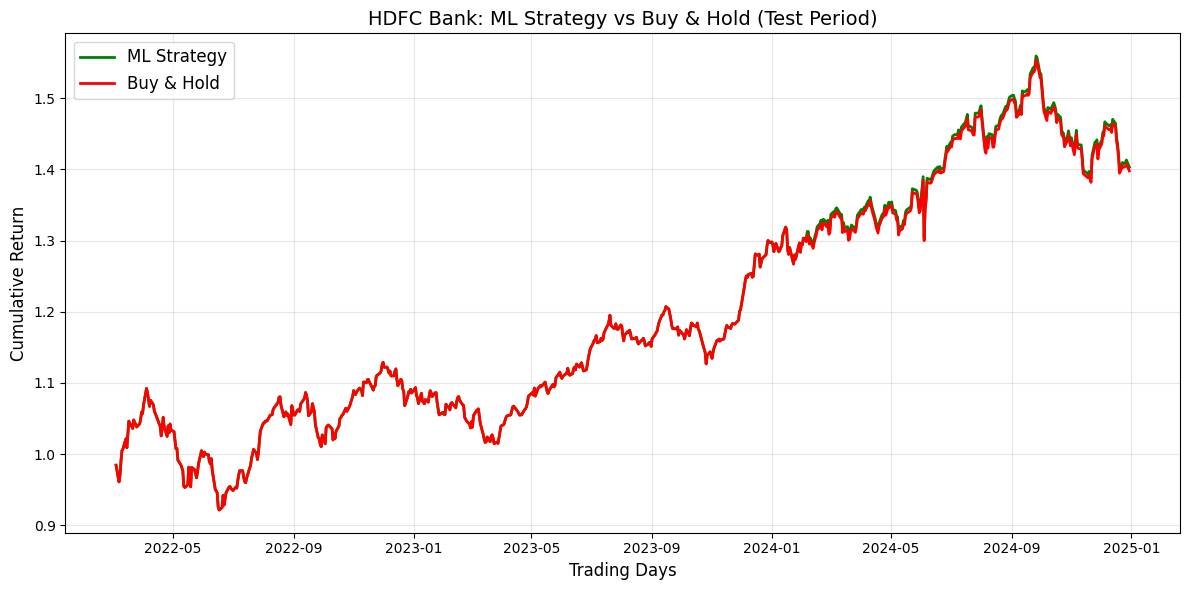

In [214]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# new kernel svm

In [216]:
from sklearn.svm import SVR

svr_model = SVR(kernel="linear", C=10, epsilon=0.1, gamma="scale")

svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")
print("Kernel:", svr_model.kernel)
print("C:", svr_model.C)
print("Epsilon:", svr_model.epsilon)
print("Gamma:", svr_model.gamma)

SVR model trained successfully.
Kernel: linear
C: 10
Epsilon: 0.1
Gamma: scale


In [217]:
y_pred = svr_model.predict(X_test_scaled)

# Store predictions in a small results table for easier inspection
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_SVR": y_pred
}, index=y_test.index)

print("Prediction shape:", y_pred.shape)
print("\nFirst 10 predictions:")
print(results.head(10))

Prediction shape: (696,)

First 10 predictions:
            Actual  Predicted_SVR
Date                             
2022-03-04       0       0.330254
2022-03-07       1       0.062068
2022-03-08       1       0.271345
2022-03-09       1       0.373720
2022-03-10       1       0.497180
2022-03-11       1       0.701334
2022-03-14       0       0.594643
2022-03-15       1       0.445143
2022-03-16       1       0.552136
2022-03-17       0       0.451434


In [220]:
thrash = np.arange(y_pred.min() ,y_pred.max(),0.01)

f1=[]

for i in thrash:
    y_pred_class = (y_pred > i).astype(int)
    f1.append(f1_score(y_test, y_pred_class))
print(y_pred.min(), y_pred.max())
print(np.unique((y_pred > 0).astype(int), return_counts=True))
best_idx = np.argmax(f1)
best_threshold = thrash[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_best = (y_pred > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

-0.5130924397985385 1.4222361586874852
(array([0, 1]), array([ 19, 677], dtype=int64))
Best threshold: -0.19309243979853818
Best F1: 0.7110694183864915
Accuracy: 0.5574712643678161
Precision: 0.5532846715328467
Recall: 0.994750656167979
F1 Score: 0.7110694183864915
[[  9 306]
 [  2 379]]
              precision    recall  f1-score   support

           0       0.82      0.03      0.06       315
           1       0.55      0.99      0.71       381

    accuracy                           0.56       696
   macro avg       0.69      0.51      0.38       696
weighted avg       0.67      0.56      0.41       696



In [224]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_best

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 44.58%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : True


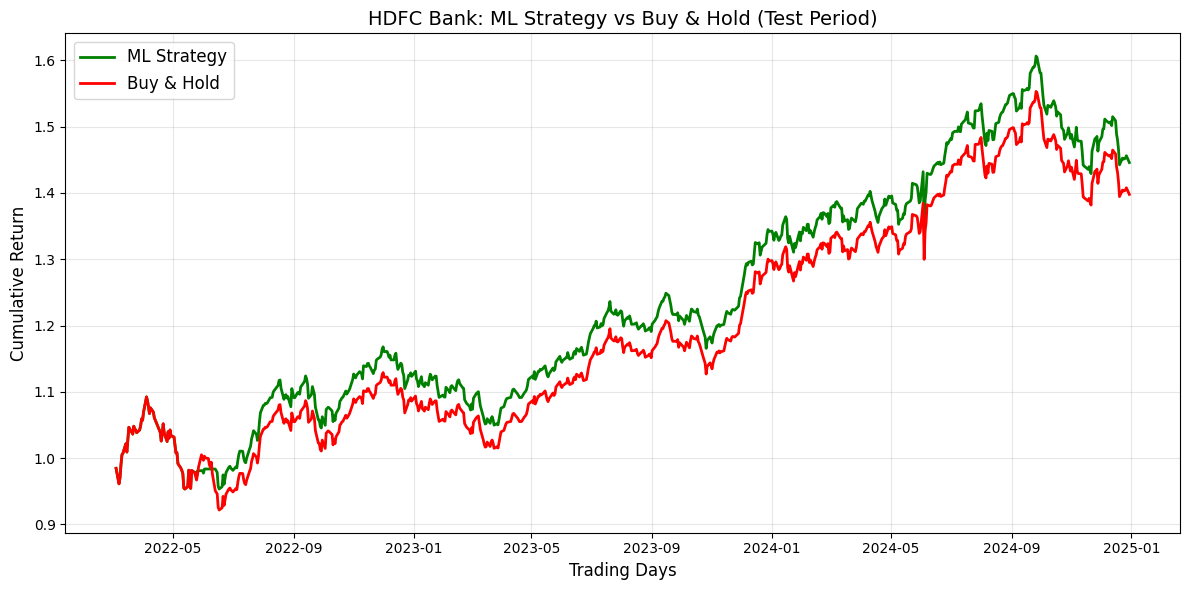

In [226]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# new kernel svm

In [230]:
from sklearn.svm import SVR

svr_model = SVR(kernel="poly", C=10, epsilon=0.1, gamma="scale")

svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")
print("Kernel:", svr_model.kernel)
print("C:", svr_model.C)
print("Epsilon:", svr_model.epsilon)
print("Gamma:", svr_model.gamma)

SVR model trained successfully.
Kernel: poly
C: 10
Epsilon: 0.1
Gamma: scale


In [232]:
y_pred = svr_model.predict(X_test_scaled)

# Store predictions in a small results table for easier inspection
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_SVR": y_pred
}, index=y_test.index)

print("Prediction shape:", y_pred.shape)
print("\nFirst 10 predictions:")
print(results.head(10))

Prediction shape: (696,)

First 10 predictions:
            Actual  Predicted_SVR
Date                             
2022-03-04       0       0.233050
2022-03-07       1       1.225701
2022-03-08       1      -0.029219
2022-03-09       1      -0.474144
2022-03-10       1      -0.480280
2022-03-11       1      -0.084710
2022-03-14       0       0.349305
2022-03-15       1       0.380782
2022-03-16       1       0.143575
2022-03-17       0       0.845098


In [234]:
thrash = np.arange(y_pred.min() ,y_pred.max(),0.01)

f1=[]

for i in thrash:
    y_pred_class = (y_pred > i).astype(int)
    f1.append(f1_score(y_test, y_pred_class))
print(y_pred.min(), y_pred.max())
print(np.unique((y_pred > 0).astype(int), return_counts=True))
best_idx = np.argmax(f1)
best_threshold = thrash[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_best = (y_pred > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

-0.48028032371094764 1.3684792949395765
(array([0, 1]), array([ 15, 681], dtype=int64))
Best threshold: -0.13028032371094733
Best F1: 0.7077497665732959
Accuracy: 0.5502873563218391
Precision: 0.5492753623188406
Recall: 0.994750656167979
F1 Score: 0.7077497665732959
[[  4 311]
 [  2 379]]
              precision    recall  f1-score   support

           0       0.67      0.01      0.02       315
           1       0.55      0.99      0.71       381

    accuracy                           0.55       696
   macro avg       0.61      0.50      0.37       696
weighted avg       0.60      0.55      0.40       696



In [236]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_best

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 34.86%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : False


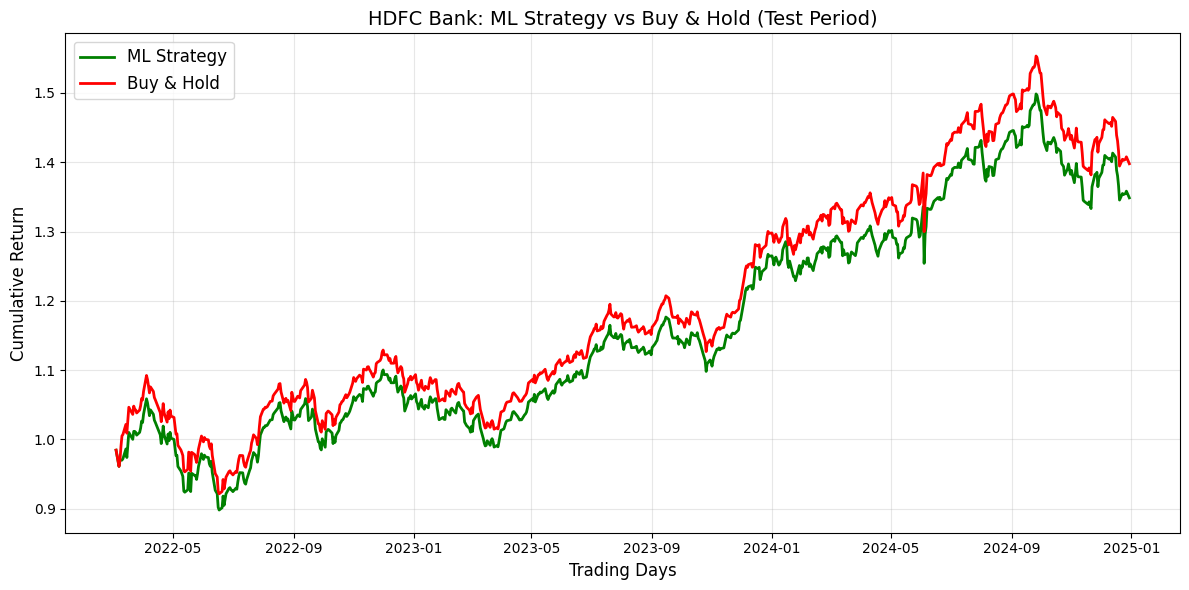

In [238]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# new kernel svm

In [245]:
from sklearn.svm import SVR

svr_model = SVR(kernel="sigmoid", C=10, epsilon=0.1, gamma="scale")

svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")
print("Kernel:", svr_model.kernel)
print("C:", svr_model.C)
print("Epsilon:", svr_model.epsilon)
print("Gamma:", svr_model.gamma)

SVR model trained successfully.
Kernel: sigmoid
C: 10
Epsilon: 0.1
Gamma: scale


In [247]:
y_pred = svr_model.predict(X_test_scaled)

# Store predictions in a small results table for easier inspection
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_SVR": y_pred
}, index=y_test.index)

print("Prediction shape:", y_pred.shape)
print("\nFirst 10 predictions:")
print(results.head(10))

Prediction shape: (696,)

First 10 predictions:
            Actual  Predicted_SVR
Date                             
2022-03-04       0    -158.917739
2022-03-07       1    -150.487828
2022-03-08       1    -543.562067
2022-03-09       1    -241.584546
2022-03-10       1     -18.341069
2022-03-11       1     -58.300682
2022-03-14       0      14.663886
2022-03-15       1       3.842578
2022-03-16       1      27.812396
2022-03-17       0       0.080676


In [249]:
thrash = np.arange(y_pred.min() ,y_pred.max(),0.01)

f1=[]

for i in thrash:
    y_pred_class = (y_pred > i).astype(int)
    f1.append(f1_score(y_test, y_pred_class))
print(y_pred.min(), y_pred.max())
print(np.unique((y_pred > 0).astype(int), return_counts=True))
best_idx = np.argmax(f1)
best_threshold = thrash[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_best = (y_pred > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

-543.5620669550123 94.22605111758075
(array([0, 1]), array([307, 389], dtype=int64))
Best threshold: -543.5620669550123
Best F1: 0.7063197026022304
Accuracy: 0.5459770114942529
Precision: 0.5467625899280576
Recall: 0.9973753280839895
F1 Score: 0.7063197026022304
[[  0 315]
 [  1 380]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       315
           1       0.55      1.00      0.71       381

    accuracy                           0.55       696
   macro avg       0.27      0.50      0.35       696
weighted avg       0.30      0.55      0.39       696



In [251]:
# Get HDFC actual log returns on the test period
test_actual_returns = all_data_return.loc[X_test.index, '^NSEI']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * y_pred_best

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 38.47%
Buy & Hold Return      : 39.78%
Strategy Outperforms   : False


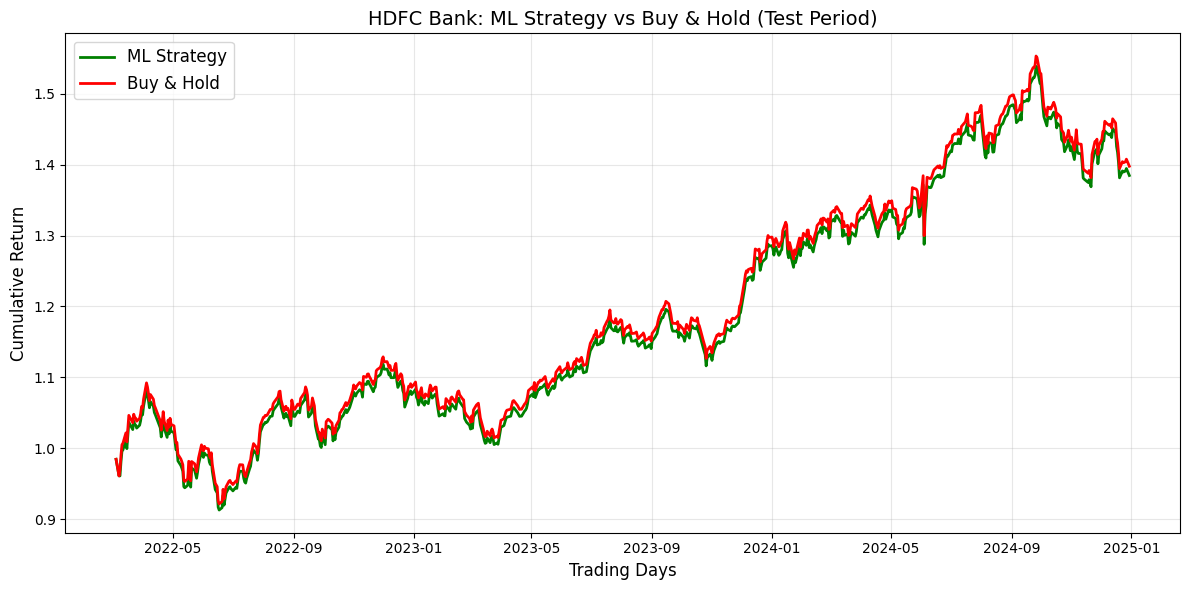

In [253]:
import matplotlib.pyplot as plt

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='ML Strategy', color='green', linewidth=2)
plt.plot(cum_buyhold, label='Buy & Hold', color='red', linewidth=2)
plt.title('HDFC Bank: ML Strategy vs Buy & Hold (Test Period)', fontsize=14)
plt.xlabel('Trading Days', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()